In [81]:
from torch.utils.data import Dataset, DataLoader, random_split
import torch
from torch import optim
import torch.nn.functional as tf
from classifiers import SimpleRHClassifier
from scipy.io import arff
import numpy as np

Load data from .arff file.

In [2]:
data = arff.loadarff("../data/msd_rh_genres.arff")

First 60 entries of each data instance is the bin values for the rhythm histogram, while the last entry is the label.

In [3]:
features = np.empty((len(data[0]), 60))
for i, entry in enumerate(data[0]):
    e = list(entry)[:60]
    features[i] = np.array(e)

In [4]:
genres_set = set()
for i, entry in enumerate(data[0]):
    genres_set.add(entry[-1])

genres = list(genres_set)
genre_to_idx = {}
for i, g in enumerate(genres):
    genre_to_idx[g] = i

print(genre_to_idx)

{b'Pop_Rock': 0, b'International': 1, b'Reggae': 2, b'Folk': 3, b'RnB': 4, b'Country': 5, b'Jazz': 6, b'Vocal': 7, b'Rap': 8, b'Latin': 9, b'Blues': 10, b'New Age': 11, b'Electronic': 12}


In [5]:
gt_labels = np.empty(len(data[0]))
for i, entry in enumerate(data[0]):
    gt_labels[i] = genre_to_idx[entry[-1]]

print(gt_labels)

[ 0.  0.  0. ...  1. 10.  3.]


Now we have features and ground truth labels ready, split them into train/test sets.

In [53]:
class GenresDataset(Dataset):
    def __init__(self, transform=None, target_transform=None):
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(data[0])

    def __getitem__(self, idx):
        feature = torch.FloatTensor(features[idx])
        label = gt_labels[idx]
        if self.transform:
            feature = self.transform(feature)
        if self.target_transform:
            label = self.target_transform(label)
        return feature, label

dataset = GenresDataset()
test_ratio = 0.2
batch_size = 64
test_size = int(len(dataset) * test_ratio)
train_size = len(dataset) - test_size
train_set, test_set = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_set, batch_size=batch_size)
test_loader = DataLoader(test_set, batch_size=batch_size)

Let's visualize the rhythm histogram for several training instances.

In [57]:
sample = enumerate(train_loader)
_, (sample_features, sample_labels) = next(sample)
print(sample_features.shape)

torch.Size([64, 60])


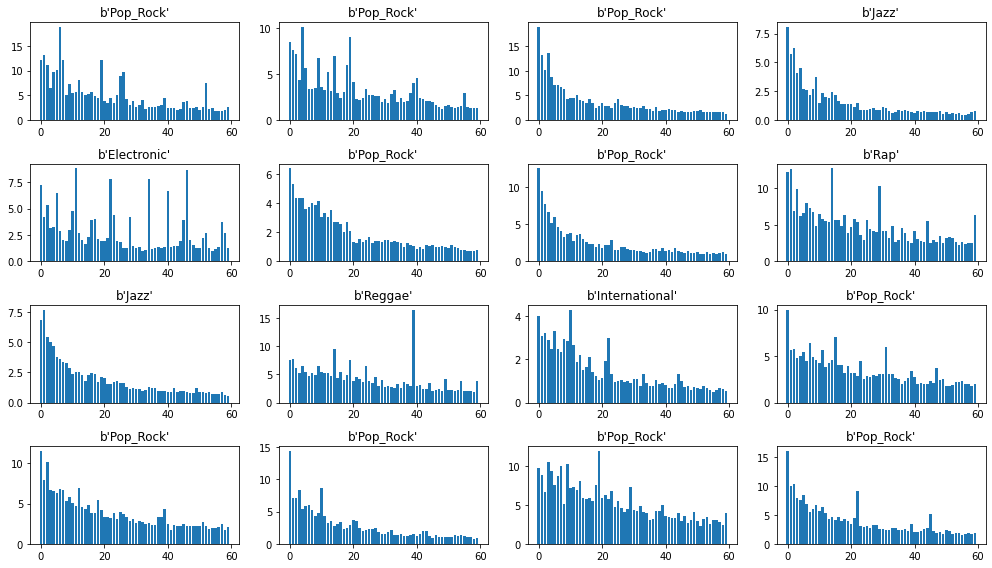

In [58]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(figsize=(14, 8))

for i in range(16):
    plt.subplot(4,4, i + 1)
    plt.tight_layout()
    plt.bar(range(60), sample_features[i])
    plt.title(genres[int(sample_labels[i])])

plt.savefig("figures/rh_visualization.png")

Train with a very simple neural network architecture (1 hidden layer of 100 neurons) for proof of concept.

In [82]:
epochs = 5
lr = 0.0001
log_interval = 1000
network = SimpleRHClassifier()
optimizer = optim.SGD(network.parameters(), lr=lr)

train_losses = []
train_counter = []
test_losses = []
test_counter = [i*len(train_loader.dataset) for i in range(epochs + 1)]

def train(ep):
  network.train()
  for batch_idx, (feature, label) in enumerate(train_loader):
    optimizer.zero_grad()
    output = network(feature)
    loss = tf.cross_entropy(output, label.long())
    loss.backward()
    optimizer.step()
    if batch_idx % log_interval == 0:
      print('Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
        ep, batch_idx * len(feature), len(train_loader.dataset),
        100. * batch_idx / len(train_loader), loss.item()))
      train_losses.append(loss.item())
      train_counter.append(
        (batch_idx * 64) + ((epoch - 1) * len(train_loader.dataset)))

def test():
  network.eval()
  test_loss = 0
  correct = 0
  with torch.no_grad():
    for feature, label in test_loader:
      output = network(feature)
      test_loss += tf.cross_entropy(output, label.long(), size_average=False).item()
      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(label.data.view_as(pred)).sum()
  test_loss /= len(test_loader.dataset)
  test_losses.append(test_loss)
  print('\nTest set: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
    test_loss, correct, len(test_loader.dataset),
    100. * correct / len(test_loader.dataset)))

In [83]:
from tqdm import tqdm

test()
for epoch in range(1, epochs + 1):
  train(epoch)
  test()


Test set: Avg. loss: 2.5894, Accuracy: 3912/80829 (5%)

Epoch: 1 [0/323317 (0%)]	Loss: 2.585631
Epoch: 1 [64000/323317 (20%)]	Loss: 2.512233
Epoch: 1 [128000/323317 (40%)]	Loss: 2.131057
Epoch: 1 [192000/323317 (59%)]	Loss: 2.050897
Epoch: 1 [256000/323317 (79%)]	Loss: 2.189737
Epoch: 1 [320000/323317 (99%)]	Loss: 2.009878

Test set: Avg. loss: 2.1186, Accuracy: 47223/80829 (58%)

Epoch: 2 [0/323317 (0%)]	Loss: 2.111608
Epoch: 2 [64000/323317 (20%)]	Loss: 2.074816
Epoch: 2 [128000/323317 (40%)]	Loss: 2.075715
Epoch: 2 [192000/323317 (59%)]	Loss: 2.026232
Epoch: 2 [256000/323317 (79%)]	Loss: 2.182800
Epoch: 2 [320000/323317 (99%)]	Loss: 2.004069

Test set: Avg. loss: 2.1115, Accuracy: 47223/80829 (58%)

Epoch: 3 [0/323317 (0%)]	Loss: 2.103353
Epoch: 3 [64000/323317 (20%)]	Loss: 2.068619
Epoch: 3 [128000/323317 (40%)]	Loss: 2.070420
Epoch: 3 [192000/323317 (59%)]	Loss: 2.022387
Epoch: 3 [256000/323317 (79%)]	Loss: 2.180771
Epoch: 3 [320000/323317 (99%)]	Loss: 2.002777

Test set: Avg. lo